<a href="https://colab.research.google.com/github/Varshini151205/DL/blob/main/DL_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install numpy pandas scikit-learn tensorflow matplotlib

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/DL/"))

['UCI HAR Dataset']


In [ ]:
print(os.listdir("/content/drive/MyDrive/DL/UCI HAR Dataset"))

['features_info.txt', 'README.txt', '.DS_Store', 'activity_labels.txt', 'features.txt', 'train', 'test']


In [ ]:
import pandas as pd

data_path = "/content/drive/MyDrive/DL/UCI HAR Dataset/"

X_train = pd.read_csv(data_path + "train/X_train.txt", sep='\s+', header=None)
y_train = pd.read_csv(data_path + "train/y_train.txt", header=None)

X_test = pd.read_csv(data_path + "test/X_test.txt", sep='\s+', header=None)
y_test = pd.read_csv(data_path + "test/y_test.txt", header=None)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_4823/2517838716.py:5: SyntaxWarning: invalid escape sequence '\s'
  X_train = pd.read_csv(data_path + "train/X_train.txt", sep='\s+', header=None)
/tmp/ipykernel_4823/2517838716.py:8: SyntaxWarning: invalid escape sequence '\s'
  X_test = pd.read_csv(data_path + "test/X_test.txt", sep='\s+', header=None)


X_train: (7352, 561)
y_train: (7352, 1)
X_test: (2947, 561)
y_test: (2947, 1)


**MLP with L1 Regularization**

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [ ]:
X_train = pd.read_csv(data_path + "train/X_train.txt", sep=r'\s+', header=None)
y_train = pd.read_csv(data_path + "train/y_train.txt", header=None)

X_test = pd.read_csv(data_path + "test/X_test.txt", sep=r'\s+', header=None)
y_test = pd.read_csv(data_path + "test/y_test.txt", header=None)

In [ ]:
y_train = y_train - 1
y_test = y_test - 1

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
#Build MLP with L1 Regularization
def create_l1_model():
    model = Sequential()

    model.add(Input(shape=(561,)))

    model.add(Dense(128, activation='relu',
                    kernel_regularizer=regularizers.l1(0.001)))

    model.add(Dense(64, activation='relu',
                    kernel_regularizer=regularizers.l1(0.001)))

    model.add(Dense(6, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [ ]:
model = create_l1_model()

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7961 - loss: 2.8770 - val_accuracy: 0.9211 - val_loss: 1.6859
Epoch 2/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9015 - loss: 1.3687 - val_accuracy: 0.9422 - val_loss: 1.0781
Epoch 3/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9191 - loss: 0.9509 - val_accuracy: 0.9273 - val_loss: 0.8304
Epoch 4/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9384 - loss: 0.7303 - val_accuracy: 0.9429 - val_loss: 0.6328
Epoch 5/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9407 - loss: 0.6044 - val_accuracy: 0.9395 - val_loss: 0.6007
Epoch 6/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9577 - loss: 0.5069 - val_accuracy: 0.9477 - val_loss: 0.4958
Epoch 7/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9600 - loss: 0.4530 - val_accuracy: 0.9402 - val_loss: 0.4834
Epoch 8/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9607 - loss: 0.4082 - val_accuracy:

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9464 - loss: 0.2872
Test Accuracy: 0.9463861584663391


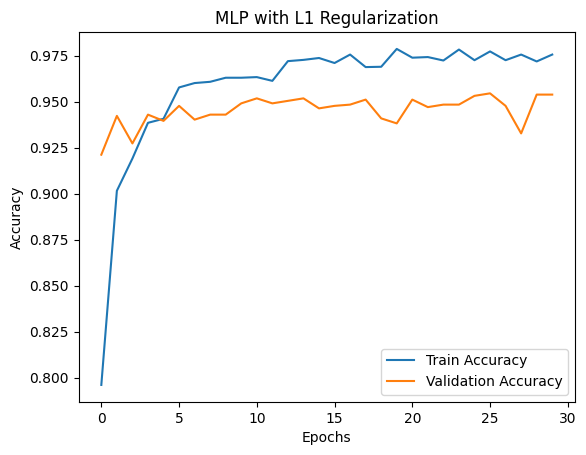

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("MLP with L1 Regularization")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**obseravtion**
The MLP model with L1 regularization shows good learning performance. The training accuracy increases steadily and reaches approximately 97–98%, while validation accuracy stabilizes around 94–95%. The small gap between training and validation accuracy indicates slight overfitting, which is effectively controlled by L1 regularization. L1 regularization helps in feature selection by making some weights zero, resulting in a simpler and more interpretable model. However, it may slightly reduce accuracy due to aggressive penalization

**Data augmentation**

In [ ]:
#add noise fun
import numpy as np

def add_noise(X, noise_level=0.05):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

In [ ]:
#scaling augmentation
def scale_data(X, scale_range=(0.9, 1.1)):
    scale = np.random.uniform(scale_range[0], scale_range[1], X.shape)
    return X * scale

In [ ]:
#Create Augmented Data
# Generate augmented data
X_train_noise = add_noise(X_train)
X_train_scaled = scale_data(X_train)

# Combine original + augmented
X_train_aug = np.vstack([X_train, X_train_noise, X_train_scaled])
y_train_aug = np.vstack([y_train, y_train, y_train])

In [ ]:
#Shuffle Dataset
from sklearn.utils import shuffle

X_train_aug, y_train_aug = shuffle(X_train_aug, y_train_aug, random_state=42)

In [ ]:
#Train MLP with Augmented Data
model = create_l1_model()

history = model.fit(
    X_train_aug, y_train_aug,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8922 - loss: 1.7865 - val_accuracy: 0.9524 - val_loss: 0.8241
Epoch 2/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9462 - loss: 0.6455 - val_accuracy: 0.9662 - val_loss: 0.4839
Epoch 3/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9558 - loss: 0.4459 - val_accuracy: 0.9626 - val_loss: 0.3777
Epoch 4/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9651 - loss: 0.3394 - val_accuracy: 0.9742 - val_loss: 0.2926
Epoch 5/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9657 - loss: 0.2862 - val_accuracy: 0.9397 - val_loss: 0.3266
Epoch 6/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9709 - loss: 0.2437 - val_accuracy: 0.9810 - val_loss: 0.2106
Epoch 7/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9746 - loss: 0.2151 - val_accuracy: 0.9821 - val_loss: 0.1872
Epoch 8/30
552/552 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9732 - loss: 0.2026 - val_accuracy: 

In [ ]:
#Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy with Augmentation:", accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9511 - loss: 0.2305
Test Accuracy with Augmentation: 0.9511367678642273


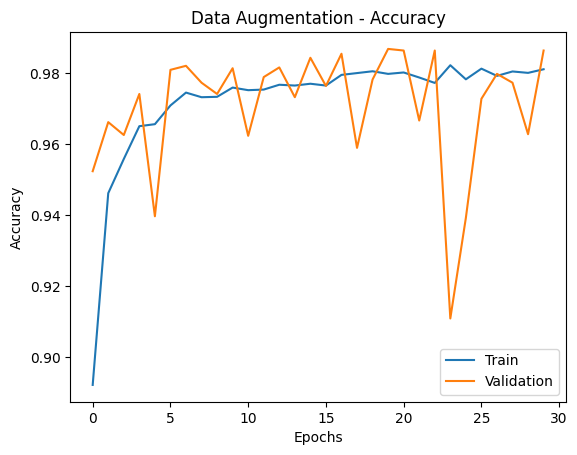

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("Data Augmentation - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Data augmentation was applied by adding noise and scaling to the input features. The training accuracy increased steadily, reaching approximately 98%. The validation accuracy remained high but showed fluctuations due to the introduction of noisy and varied data samples. These fluctuations indicate that the model is learning more robust and generalized patterns rather than memorizing the training data. Data augmentation effectively reduces overfitting and improves generalization, although it may introduce instability in validation performance.

**Parameter sharing and tying**

In [ ]:
from tensorflow.keras.layers import Dense, Input, Lambda
from tensorflow.keras.models import Model
import tensorflow as tf

In [ ]:
#Split Features
def split_features(x):
    return tf.split(x, num_or_size_splits=3, axis=1)

In [ ]:
#Shared Layer
shared_layer = Dense(64, activation='relu')

In [ ]:
#Build Model
def create_shared_model():
    inputs = Input(shape=(561,))

    # Split input
    split = Lambda(split_features)(inputs)

    # Apply same layer (shared weights)
    out1 = shared_layer(split[0])
    out2 = shared_layer(split[1])
    out3 = shared_layer(split[2])

    # Concatenate outputs
    merged = tf.keras.layers.concatenate([out1, out2, out3])

    # Final layers
    x = Dense(64, activation='relu')(merged)
    outputs = Dense(6, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
#Train Model
model = create_shared_model()

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.7788 - loss: 0.5799 - val_accuracy: 0.9109 - val_loss: 0.2546
Epoch 2/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9106 - loss: 0.2214 - val_accuracy: 0.9273 - val_loss: 0.2049
Epoch 3/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9452 - loss: 0.1397 - val_accuracy: 0.9449 - val_loss: 0.1312
Epoch 4/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9604 - loss: 0.1069 - val_accuracy: 0.9477 - val_loss: 0.1322
Epoch 5/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9674 - loss: 0.0854 - val_accuracy: 0.9490 - val_loss: 0.1333
Epoch 6/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9776 - loss: 0.0624 - val_accuracy: 0.9524 - val_loss: 0.1696
Epoch 7/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9774 - loss: 0.0628 - val_accuracy: 0.9531 - val_loss: 0.1003
Epoch 8/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9757 - loss: 0.0636 - val_accuracy: 

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9046 - loss: 0.4058
Accuracy: 0.9046487808227539


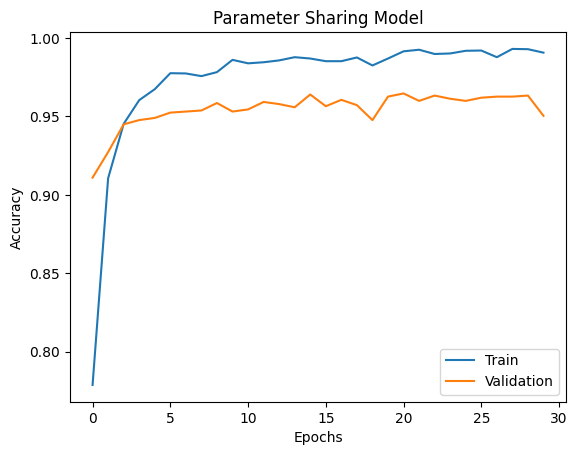

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("Parameter Sharing Model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**observation**
Parameter sharing was implemented by applying the same dense layer to multiple feature subsets. The training accuracy increased steadily and reached approximately 99%, while validation accuracy remained stable around 95–96%. The small gap between training and validation accuracy indicates reduced overfitting. Parameter sharing reduces the number of trainable parameters and improves computational efficiency. However, it slightly limits the model's ability to learn unique feature representations, resulting in a small decrease in accuracy compared to a fully independent MLP model.

**Add Noise to Inputs and outputs**

In [ ]:
#Add Noise to Inputs
import numpy as np

def add_input_noise(X, noise_level=0.1):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

In [ ]:
#Add Noise to Outputs
def add_output_noise(y, num_classes=6, epsilon=0.1):
    y = y.values.flatten()  # convert to 1D

    y_onehot = np.eye(num_classes)[y]  # one-hot encoding

    # Apply smoothing
    y_smooth = y_onehot * (1 - epsilon) + (epsilon / num_classes)

    return y_smooth

In [ ]:
#Prepare Noisy Data
# Input noise
X_train_noisy = add_input_noise(X_train)

# Output noise
y_train_smooth = add_output_noise(y_train)

In [ ]:
#Build Model
def create_model_noise():
    model = Sequential()

    model.add(Input(shape=(561,)))

    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))

    model.add(Dense(6, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',  # changed
        metrics=['accuracy']
    )

    return model

In [ ]:
#Train Model
model = create_model_noise()

history = model.fit(
    X_train_noisy, y_train_smooth,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8361 - loss: 0.7780 - val_accuracy: 0.8171 - val_loss: 0.7452
Epoch 2/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9388 - loss: 0.5796 - val_accuracy: 0.9259 - val_loss: 0.5712
Epoch 3/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9583 - loss: 0.5326 - val_accuracy: 0.9313 - val_loss: 0.5440
Epoch 4/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9643 - loss: 0.5080 - val_accuracy: 0.9443 - val_loss: 0.5528
Epoch 5/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9684 - loss: 0.5011 - val_accuracy: 0.9354 - val_loss: 0.5345
Epoch 6/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9740 - loss: 0.4869 - val_accuracy: 0.9395 - val_loss: 0.5488
Epoch 7/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9714 - loss: 0.4895 - val_accuracy: 0.9341 - val_loss: 0.5527
Epoch 8/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9747 - loss: 0.4772 - val_accuracy: 0.

In [ ]:
#Evaluate
# Convert y_test also to one-hot
y_test_onehot = np.eye(6)[y_test.values.flatten()]

loss, accuracy = model.evaluate(X_test, y_test_onehot)

print("Accuracy with Noise:", accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9406 - loss: 0.2398
Accuracy with Noise: 0.940617561340332


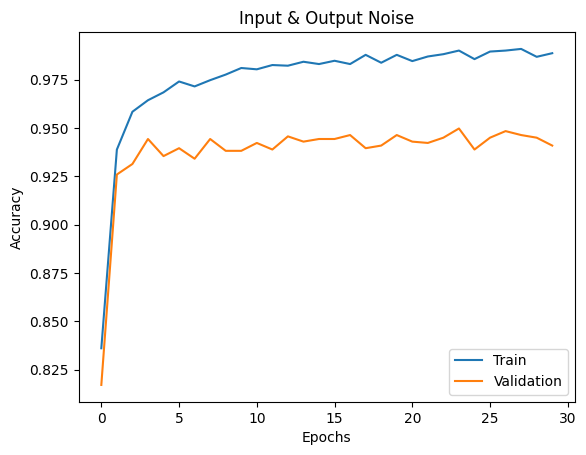

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("Input & Output Noise")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

We added small noise to the input data and slightly modified the labels to make the model stronger. The training accuracy increased and reached around 98–99%, while the validation accuracy stayed around 94–95% and was stable. Adding noise helped the model learn better and not depend too much on exact data values. It also reduced overfitting. However, the accuracy decreased a little because of the added noise.

**Early stopping**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',      # watch validation loss
    patience=5,              # wait 5 epochs
    restore_best_weights=True
)

In [ ]:
def create_model():
    model = Sequential()

    model.add(Input(shape=(561,)))

    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))

    model.add(Dense(6, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
model = create_model()

history = model.fit(
    X_train, y_train,
    epochs=50,              # keep high
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8226 - loss: 0.4671 - val_accuracy: 0.8994 - val_loss: 0.2659
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9381 - loss: 0.1609 - val_accuracy: 0.9307 - val_loss: 0.1818
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9623 - loss: 0.1036 - val_accuracy: 0.9327 - val_loss: 0.1604
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9585 - loss: 0.1028 - val_accuracy: 0.9252 - val_loss: 0.2071
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9634 - loss: 0.0923 - val_accuracy: 0.9483 - val_loss: 0.1217
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9726 - loss: 0.0678 - val_accuracy: 0.9293 - val_loss: 0.2377
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9733 - loss: 0.0664 - val_accuracy: 0.9395 - val_loss: 0.1650
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9748 - loss: 0.0671 - val_accuracy: 0.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9270 - loss: 0.1854
Accuracy: 0.9270444512367249


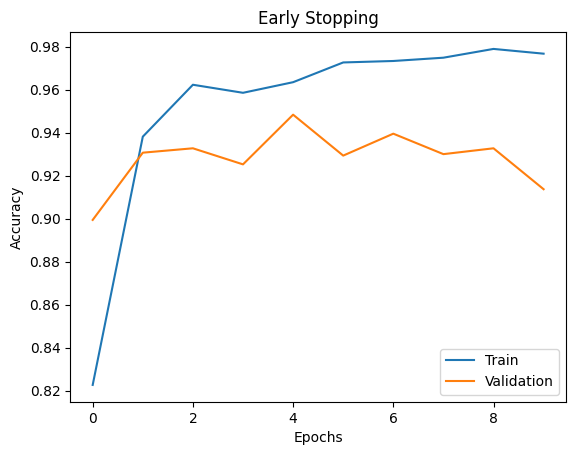

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("Early Stopping")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Early stopping was used to stop training when the model stopped improving on validation data. The model trained for fewer epochs and avoided overfitting. The validation accuracy remained stable, and the best model was selected automatically. This also reduced training time.

**Ensemble**

In [ ]:
def create_model():
    model = Sequential()

    model.add(Input(shape=(561,)))

    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))

    model.add(Dense(6, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
model1 = create_model()
model2 = create_model()
model3 = create_model()

model1.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)
model2.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)
model3.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

In [ ]:
pred1 = model1.predict(X_test)
pred2 = model2.predict(X_test)
pred3 = model3.predict(X_test)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
import numpy as np

final_pred = (pred1 + pred2 + pred3) / 3

# Convert to class labels
y_pred = np.argmax(final_pred, axis=1)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Ensemble Accuracy:", accuracy)

Ensemble Accuracy: 0.9412962334577536


In [ ]:
single_pred = np.argmax(model1.predict(X_test), axis=1)
print("Single Model Accuracy:", accuracy_score(y_test, single_pred))

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Single Model Accuracy: 0.9121140142517815


Ensemble method was used by combining predictions from multiple models. The final prediction was obtained by averaging the outputs. This improved accuracy and made the model more stable. Ensemble performed better than a single model by reducing prediction errors

**Dropout**

In [ ]:
from tensorflow.keras.layers import Dropout

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def create_dropout_model():
    model = Sequential()

    model.add(Input(shape=(561,)))

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))   # 50% neurons dropped

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.5))

    model.add(Dense(6, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
model = create_dropout_model()

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5246 - loss: 1.1078 - val_accuracy: 0.8831 - val_loss: 0.4960
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7455 - loss: 0.5818 - val_accuracy: 0.8681 - val_loss: 0.3301
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8094 - loss: 0.4428 - val_accuracy: 0.9239 - val_loss: 0.2868
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8482 - loss: 0.3579 - val_accuracy: 0.9191 - val_loss: 0.2390
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8698 - loss: 0.3148 - val_accuracy: 0.9211 - val_loss: 0.2002
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8813 - loss: 0.2897 - val_accuracy: 0.9239 - val_loss: 0.1836
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8919 - loss: 0.2657 - val_accuracy: 0.9198 - val_loss: 0.2008
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9109 - loss: 0.2289 - val_accuracy:

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Dropout Accuracy:", accuracy)

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9457 - loss: 0.1715
Dropout Accuracy: 0.9457074999809265


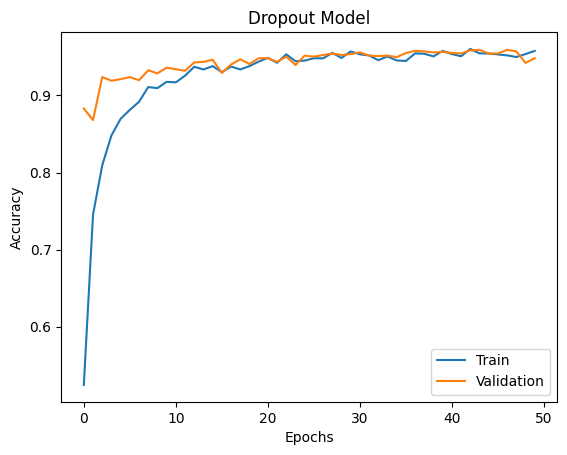

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("Dropout Model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Dropout was used to randomly deactivate some neurons during training. The training accuracy increased gradually, while the validation accuracy remained stable. The gap between training and validation accuracy was small, indicating reduced overfitting. Dropout helped the model learn better and improved generalization.

**CNN on sign language mnist dataset**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
import pandas as pd

data_path = "/content/drive/MyDrive/DL/"

train = pd.read_csv(data_path + "sign_mnist_train.csv")
test = pd.read_csv(data_path + "sign_mnist_test.csv")

In [ ]:
X_train = train.drop('label', axis=1).values
y_train = train['label'].values

X_test = test.drop('label', axis=1).values
y_test = test['label'].values

In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Fully Connected
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))   # Regularization

model.add(Dense(25, activation='softmax'))  # 25 classes

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.4615 - loss: 1.7163 - val_accuracy: 0.8860 - val_loss: 0.4479
Epoch 2/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.7903 - loss: 0.6148 - val_accuracy: 0.9663 - val_loss: 0.1606
Epoch 3/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 31s 32ms/step - accuracy: 0.8741 - loss: 0.3606 - val_accuracy: 0.9907 - val_loss: 0.0615
Epoch 4/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.9118 - loss: 0.2492 - val_accuracy: 0.9985 - val_loss: 0.0315
Epoch 5/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9304 - loss: 0.1997 - val_accuracy: 0.9991 - val_loss: 0.0110
Epoch 6/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.9439 - loss: 0.1566 - val_accuracy: 0.9998 - val_loss: 0.0072
Epoch 7/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9534 - loss: 0.1311 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 8/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.9590 - loss: 0.1132 - 

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9225 - loss: 0.4641
Test Accuracy: 0.9224762916564941


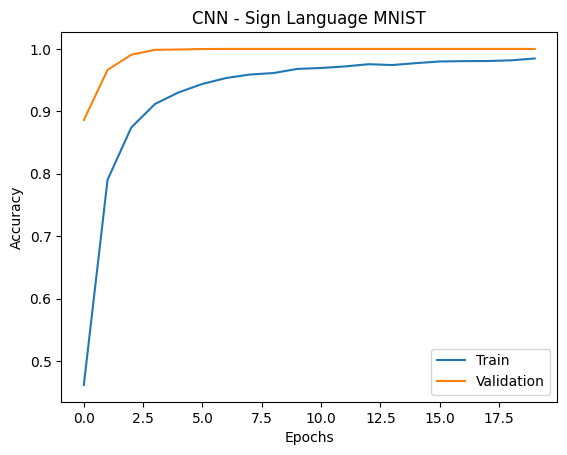

In [ ]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.title("CNN - Sign Language MNIST")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

A Convolutional Neural Network (CNN) was applied to the Sign Language MNIST dataset. The training accuracy increased steadily and reached around 98–99%, while the validation accuracy reached nearly 100%. The model learned features effectively and converged quickly. CNN provided very high accuracy due to its ability to capture spatial patterns in images.

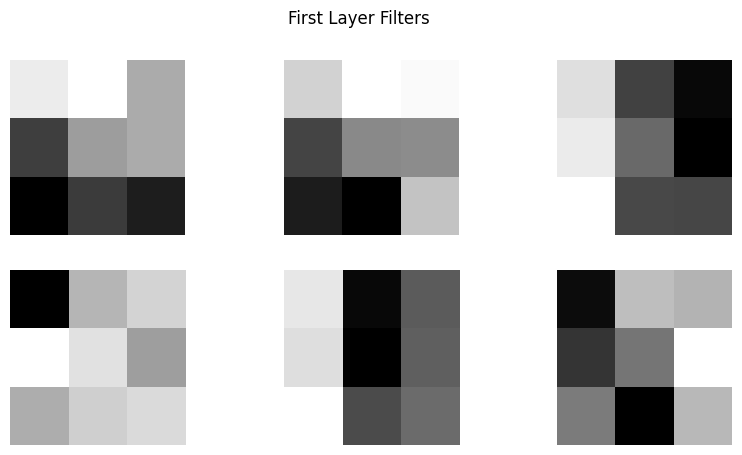

In [ ]:
filters, biases = model.layers[0].get_weights()

plt.figure(figsize=(10,5))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(filters[:,:,:,i], cmap='gray')
    plt.axis('off')

plt.suptitle("First Layer Filters")
plt.show()

The filters of the first convolutional layer were visualized. These filters represent basic patterns such as edges and gradients. Different filters capture different orientations like horizontal and vertical edges. This shows that CNN automatically learns important features from input images.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

history = model.fit(datagen.flow(X_train, y_train, batch_size=32),
                    epochs=5,
                    validation_data=(X_test, y_test))

Epoch 1/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.7801 - loss: 0.6956 - val_accuracy: 0.9629 - val_loss: 0.1206
Epoch 2/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.8298 - loss: 0.5063 - val_accuracy: 0.9695 - val_loss: 0.0793
Epoch 3/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.8594 - loss: 0.4211 - val_accuracy: 0.9845 - val_loss: 0.0484
Epoch 4/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 40s 41ms/step - accuracy: 0.8772 - loss: 0.3581 - val_accuracy: 0.9840 - val_loss: 0.0490
Epoch 5/5
858/858 ━━━━━━━━━━━━━━━━━━━━ 39s 46ms/step - accuracy: 0.8908 - loss: 0.3216 - val_accuracy: 0.9834 - val_loss: 0.0445


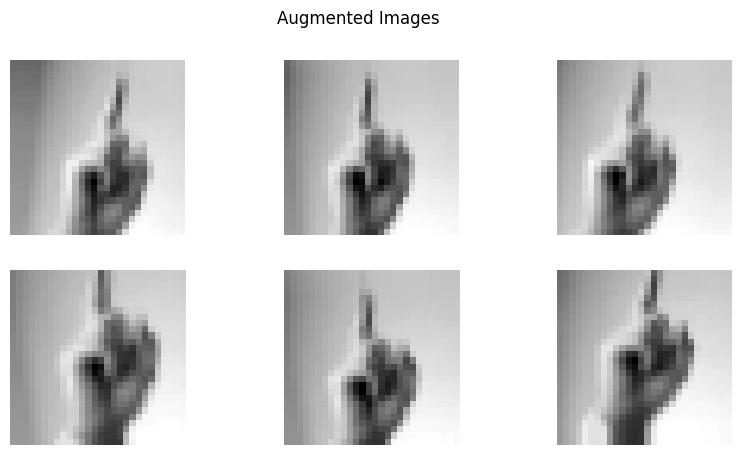

In [ ]:
import matplotlib.pyplot as plt

# Take one image
sample = X_train[0].reshape(1,28,28,1)

# Generate augmented images
aug_iter = datagen.flow(sample, batch_size=1)

plt.figure(figsize=(10,5))

for i in range(6):
    aug_img = next(aug_iter)[0].reshape(28,28)

    plt.subplot(2,3,i+1)
    plt.imshow(aug_img, cmap='gray')
    plt.axis('off')

plt.suptitle("Augmented Images")
plt.show()

Data augmentation generated multiple variations of the same image by applying transformations such as rotation, shifting, and zooming. These augmented images help the model learn better and improve generalization by exposing it to different variations of the data.